# Examining Active Region Features of the Lower Solar Atmosphere

In this tutorial, we will examine images of a solar active region at different wavelength passbands:
* optical continuum (SDO/HMI)
* 1600 $\AA$ continuum (SDO/AIA)
* He II 304 $\AA$ (He II Lyman alpha line; SOD/AIA)

and consider what we can infer about the different features present in each based on our understanding of the solar atmosphere.

## Install relevant packages

In [1]:
!pip install -q astropy
!pip install -q sunpy[all]
!pip install -q matplotlib

## Import relevant packages

In [2]:
import glob
import os.path

import astropy.units as u
import drms
import matplotlib.pyplot as plt
import sunpy.map
import sunpy.visualization.colormaps.cm as cm

from sunpy.net import Fido, attrs as a
from sunpy.time import TimeRange

## Acquire Data

### Acquire SHARP files (SHARP stands for Spaceweather HMI Active Region Patch)

In [3]:
series = 'hmi.sharp_cea_720s'
sharpnum = 377 #sharp number
segments = ['magnetogram', 'continuum']
kwlist = ['T_REC', 'LON_FWT', 'OBS_VR', 'CROTA2',
          'CRPIX1', 'CRPIX2', 'CDELT1', 'CDELT2', 'CRVAL1', 'CRVAL2']

c = drms.Client(email="daniel.ryan@ucl.ac.uk") ##Use your own email address.
k = c.query('%s[%d]' % (series, sharpnum), key=kwlist, rec_index=True)

rec_cm = k.LON_FWT.abs().idxmin()
k_cm = k.loc[rec_cm]
t_cm = drms.to_datetime(k.T_REC[rec_cm])
print(rec_cm, '@', k.LON_FWT[rec_cm], 'deg')
print('Timestamp:', t_cm)

t_cm_str = t_cm.strftime('%Y%m%d_%H%M%S_TAI')
fname_mask = '{series}.{sharpnum}.{tstr}.{segment}.fits'
fnames = {
    s: fname_mask.format(
        series=series, sharpnum=sharpnum, tstr=t_cm_str, segment=s)
    for s in segments}

download_segments = []
for k, v in fnames.items():
    if not os.path.exists(v):
        download_segments.append(k)

if download_segments:
    exp_query = '%s{%s}' % (rec_cm, ','.join(download_segments))
    r = c.export(exp_query, method='url', protocol='fits')
    dl = r.download('.')

hmi.sharp_cea_720s[377][2011.02.14_02:00:00_TAI] @ -0.038304 deg
Timestamp: 2011-02-14 02:00:00


#### Read SHARP data into sunpy maps.

In [4]:
# Define file name.
file_mag = glob.glob("*magnetogram.fits")

# Read file/data into a sunpy Map object.
map_mag = sunpy.map.Map(file_mag)

Observatory,SDO
Instrument,HMI SIDE1
Detector,HMI
Measurement,observable
Wavelength,6173.0 Angstrom
Observation Date,2011-02-14 01:58:12
Exposure Time,Unknown
Dimension,[744. 377.] pix
Coordinate System,heliographic_carrington
Scale,[0.03 0.03] deg / pix
Reference Pixel,[371.5 188. ] pix

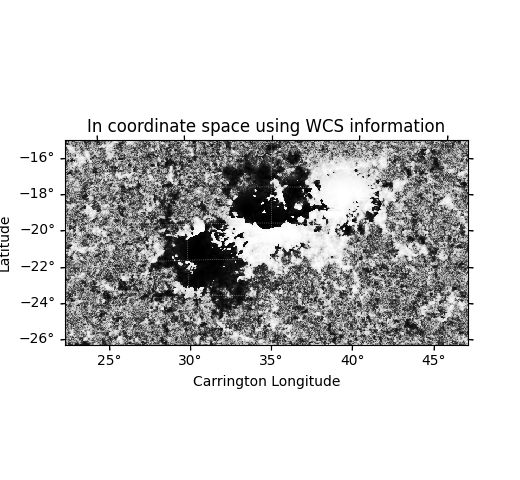
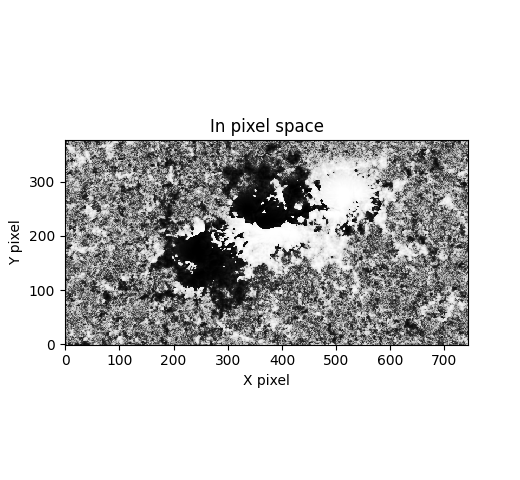
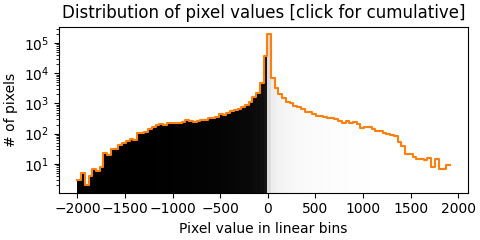
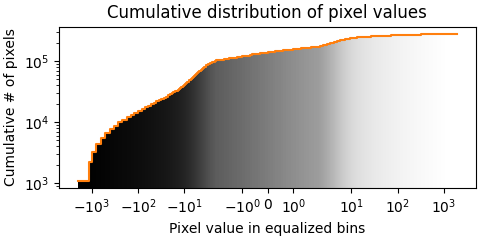

In [5]:
# Let's look at a summary of the sunpy Map
map_mag

In [6]:
# Define file name.
file_cont = glob.glob("*continuum.fits")  

# Read file/data into a sunpy Map object.
map_cont = sunpy.map.Map(file_cont)

Observatory,SDO
Instrument,HMI SIDE1
Detector,HMI
Measurement,observable
Wavelength,6173.0 Angstrom
Observation Date,2011-02-14 01:58:12
Exposure Time,Unknown
Dimension,[744. 377.] pix
Coordinate System,heliographic_carrington
Scale,[0.03 0.03] deg / pix
Reference Pixel,[371.5 188. ] pix

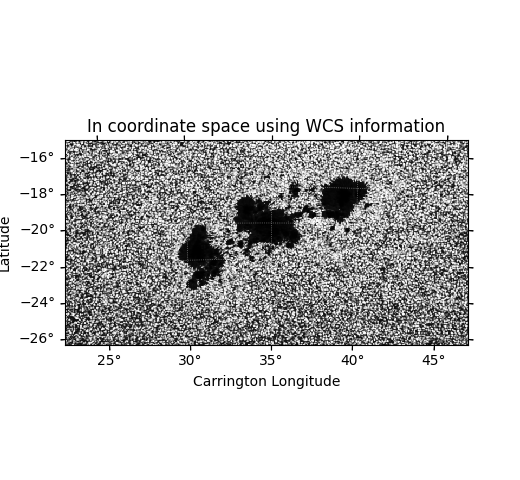
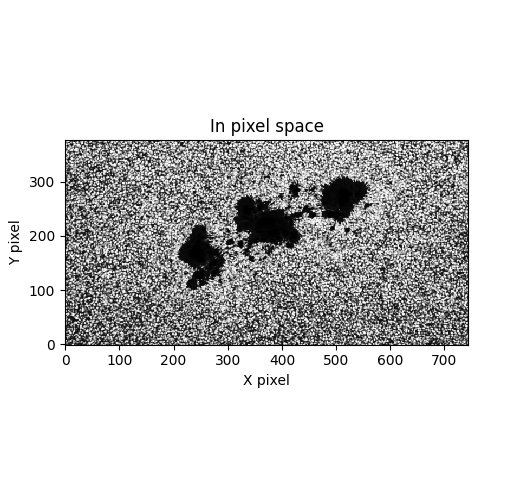
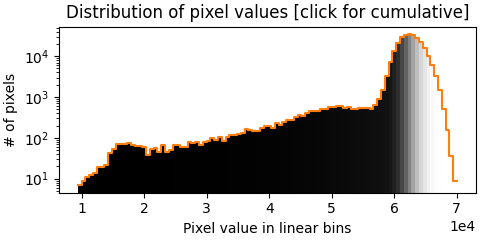
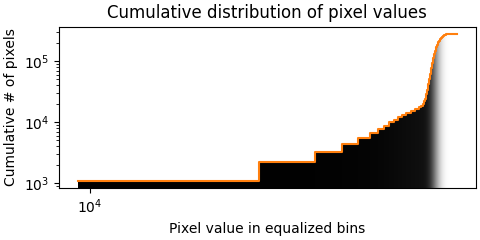

In [7]:
# Let's look at a summary of the sunpy Map
map_cont

### Acquire corresponding AIA images

Now let's use the Fido subpackage of sunpy to find and download AIA images of the same active region.

In [8]:
# Define a time range to search based on the time of HMI images.
# Let's give a time range of +/- 5 seconds around the HMI time, using astropy units, u.
search_timerange = TimeRange(map_mag.date-5*u.s, map_mag.date + 5*u.s)

#### 1600 A

In [9]:
# Find the AIA 1600 image corresponding to the same time as the above HMI images.
query_1600 = Fido.search(a.Time(search_timerange), a.Instrument.aia, a.Wavelength(1600*u.AA))

In [10]:
# Now let's use Fido to download the file to the current directory.
file_1600 = Fido.fetch(query_1600, path="./")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [11]:
# Read AIA 1600 file and crop it to the same FOV as the HMI images.
map_1600 = sunpy.map.Map(file_1600)
map_1600 = map_1600.submap(map_mag.bottom_left_coord, top_right=map_mag.top_right_coord)

Observatory,SDO
Instrument,AIA 3
Detector,AIA
Measurement,1600.0 Angstrom
Wavelength,1600.0 Angstrom
Observation Date,2011-02-14 01:58:17
Exposure Time,2.900753 s
Dimension,[641. 306.] pix
Coordinate System,helioprojective
Scale,[0.609373 0.609373] arcsec / pix
Reference Pixel,[334.47998 538.589966] pix

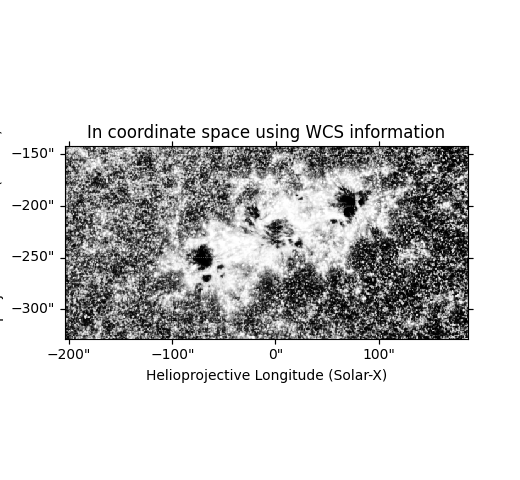
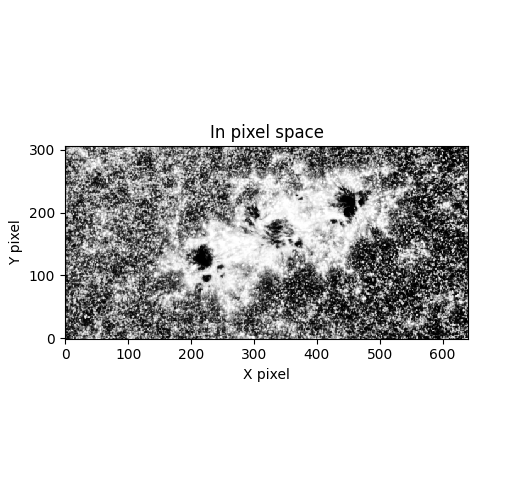
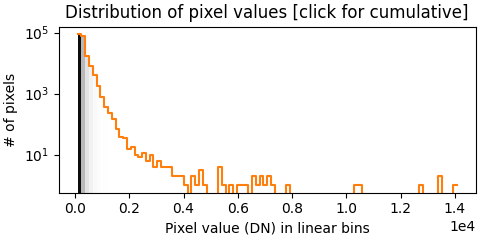
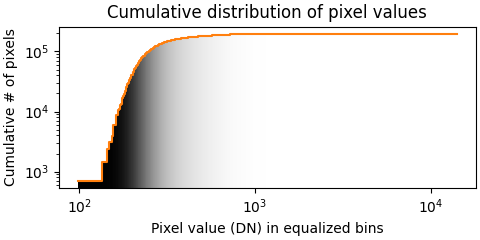

In [12]:
# Let's get a summary of the contents of the 1600 Map.
map_1600

#### 304 A

In [13]:
# Find the AIA 304 image corresponding to the same time as the above HMI images.
query_304 = Fido.search(a.Time(search_timerange), a.Instrument.aia, a.Wavelength(304*u.AA))

In [14]:
# Now let's use Fido to download the file to the current directory.
file_304 = Fido.fetch(query_304, path="./")

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [15]:
# Read AIA 304 file and crop it to same FOV as HMI maps.
map_304 = sunpy.map.Map(file_304)
map_304 = map_304.submap(map_mag.bottom_left_coord, top_right=map_mag.top_right_coord)

Observatory,SDO
Instrument,AIA 4
Detector,AIA
Measurement,304.0 Angstrom
Wavelength,304.0 Angstrom
Observation Date,2011-02-14 01:58:08
Exposure Time,2.902164 s
Dimension,[651. 312.] pix
Coordinate System,helioprojective
Scale,[0.600165 0.600165] arcsec / pix
Reference Pixel,[339.340088 547.579956] pix

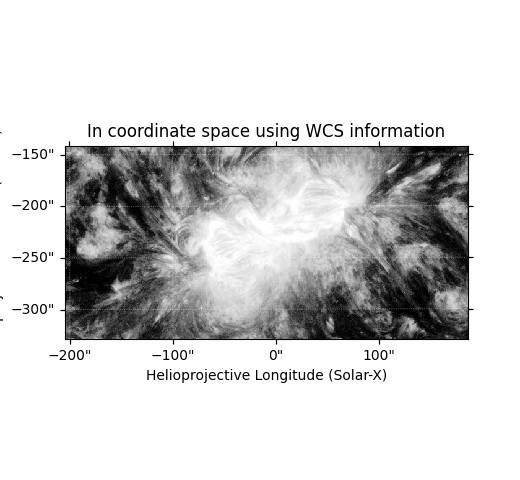
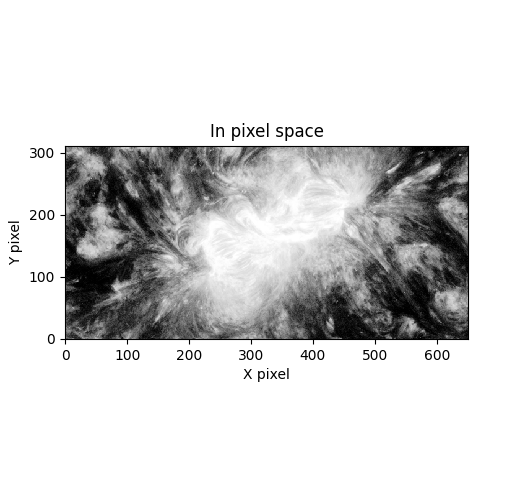
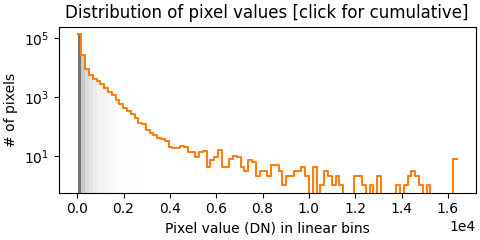
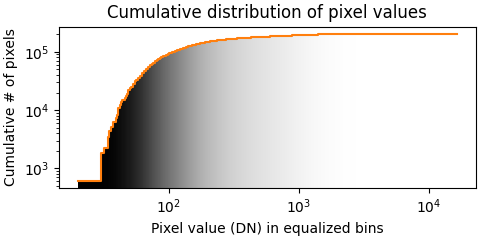

In [16]:
# Let's get a summary of the contents of the 304 Map.
map_304

## Compare intensity features at different wavelengths with magnetic features

### Calculate Contours of Magnetogram with 150G cut-off

In [17]:
lvl = 150
pos_contours = map_mag.find_contours(lvl)
neg_contours = map_mag.find_contours(-lvl)

### Plot Images

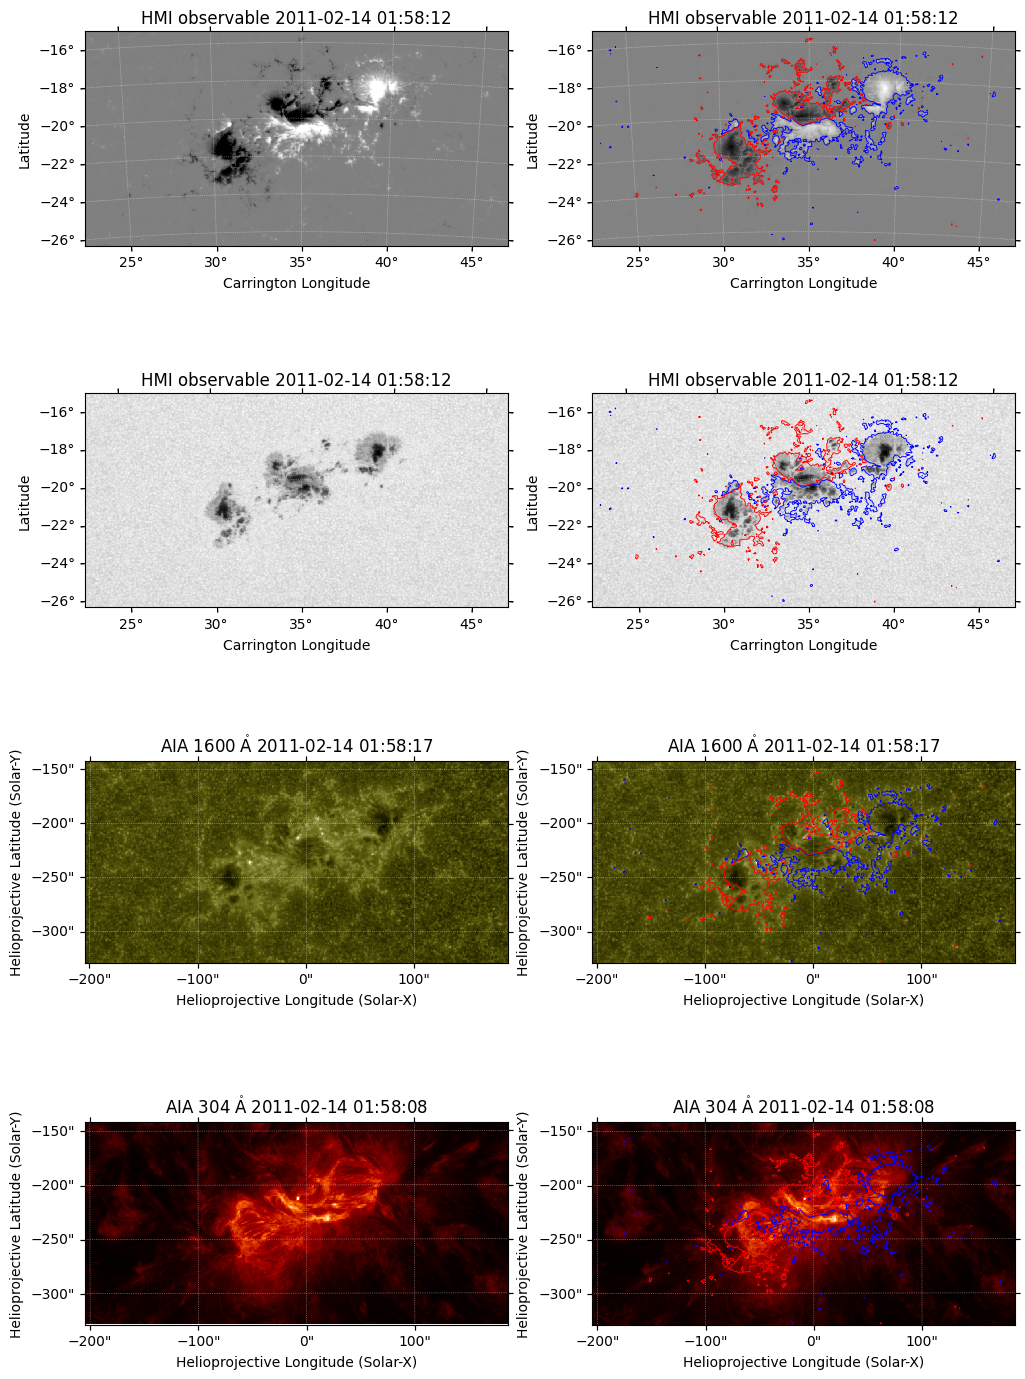

In [18]:
linewidth = 0.65

fig = plt.figure(figsize=(12, 18))

ax_mag0 = fig.add_subplot(421, projection=map_mag)
map_mag.plot(axes=ax_mag0, vmin=-1000, vmax=1000)

ax_mag = fig.add_subplot(422, projection=map_mag)
map_mag.plot(axes=ax_mag)
for contour in pos_contours:
    ax_mag.plot_coord(contour, color="blue", linewidth=linewidth)
for contour in neg_contours:
    ax_mag.plot_coord(contour, color="red", linewidth=linewidth)

ax_cont0 = fig.add_subplot(423, projection=map_cont)
map_cont.plot(axes=ax_cont0)

ax_cont = fig.add_subplot(424, projection=map_cont)
map_cont.plot(axes=ax_cont)
for contour in pos_contours:
    ax_cont.plot_coord(contour, color="blue", linewidth=linewidth)
for contour in neg_contours:
    ax_cont.plot_coord(contour, color="red", linewidth=linewidth)

ax_1600_0 = fig.add_subplot(425, projection=map_1600)
map_1600.plot(axes=ax_1600_0)

ax_1600 = fig.add_subplot(426, projection=map_1600)
map_1600.plot(axes=ax_1600)
for contour in pos_contours:
    ax_1600.plot_coord(contour, color="blue", linewidth=linewidth)
for contour in neg_contours:
    ax_1600.plot_coord(contour, color="red", linewidth=linewidth)

ax_304_0 = fig.add_subplot(427, projection=map_304)
map_304.plot(axes=ax_304_0)

ax_304 = fig.add_subplot(428, projection=map_304)
map_304.plot(axes=ax_304)
for contour in pos_contours:
    ax_304.plot_coord(contour, color="blue", linewidth=linewidth)
for contour in neg_contours:
    ax_304.plot_coord(contour, color="red", linewidth=linewidth)

## What are we looking at?

## What temperature/heights dominate these images?

Consider this plot.  Approximately where would you place the dominate emission from
* HMI optical continuum
* AIA 1600 continuum
* AIA 304 (He II emission line)

?

![title](solar_line_formation_heights.png)